### Домашнее задание 18



### Задача 1

Реализуйте удаление в дереве поиска, дополнив код с семинара. Протестируйте все случаи, включая 0, 1, 2 потомка, а также удаление корневого элемента и удаление единственного элемента дерева.

In [ ]:
"""

так вспоминаем как работает удаление

1) ищем наш node
2) если у нас нет потомков -> просто делаем node.parent.child (нужны) = None
3) если у нас есть один потомок -> ставим его на нужное место
4) если потомка два начинаются приколы)


"""

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [129]:
class TreeNode:
    def __init__(self, key, value = None):
        self.key = key
        self.value = value
        self.left_child = None
        self.right_child = None
        self.parent = None
        self.level = None

    def is_terminal(self):
        return self.left_child is None and self.right_child is None

    def draw(self, canvas, x0, y0, h, w, depth):
        cv2.circle(canvas, (x0, y0), 50, (180, 180, 180), -1)
        cv2.putText(canvas, str(self.key), (x0 - 15, y0 + 15), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 2, cv2.LINE_AA)

        if self.left_child is not None:
            x, y = int(x0 - w / (depth + 1)), y0 + h
            cv2.line(canvas, (x0, y0), (x, y), (0, 0, 0), 1)
            self.left_child.draw(canvas, x, y, h, w, depth + 1)

        if self.right_child is not None:
            x, y = int(x0 + w / (depth + 1)), y0 + h
            cv2.line(canvas, (x0, y0), (x, y), (0, 0, 0), 1)
            self.right_child.draw(canvas, x, y, h, w, depth + 1)


In [618]:
from cv2.detail import NoSeamFinder
from typing_extensions import NoDefault
class Tree:
    def __init__(self):
        self.root = None
        self.num_of_nodes = 0

    def search(self, key):
        current = self.root

        while current is not None:
            if current.key == key:
                return current

            elif current.key > key:
                current = current.left_child

            else:
                current = current.right_child

        print(f'no element with key {key} in Tree')

    def insert(self, key, value = None):
        new_node = TreeNode(key, value)

        if self.root is None:
            self.root = new_node
            new_node.level = 0
            return

        current = self.root

        while True:
            if current.key > key:
                if current.left_child is None:
                    new_node.parent = current
                    current.left_child = new_node
                    new_node.level = current.level + 1
                    self.num_of_nodes += 1
                    return

                else:
                    current = current.left_child

            elif current.key < key:
                if current.right_child is None:
                    new_node.parent = current
                    current.right_child = new_node
                    new_node.level = current.level + 1
                    self.num_of_nodes += 1
                    return

                else:
                    current = current.right_child

            elif current.key == key:
                print(f'node with key {key} is already in Tree.')
                return

    def delete(self, key):
        node = self.search(key)

        #
        # if there is no node with this key just return
        #
        if not node:
            return

        #
        # in case we want to remove the root
        #
        if not node.parent:
            if node.is_terminal():
                self.root, self.height, self.num_of_nodes = None, None, 0
                return
            if not node.right_child:
                self.root = node.left_child
                node.left_child.parent = None
                self.num_of_nodes -= 1
                return
            if not node.left_child:
                self.root = node.right_child
                node.right_child.parent = None
                self.num_of_nodes -= 1
                return

            else:
                # root has two children
                successor = self.get_successor(node)
                node.key, node.value = successor.key, successor.value

                if successor.parent.left_child == successor:
                    successor.parent.left_child = successor.right_child
                    print(successor.parent.left_child)
                else:
                    successor.parent.right_child = successor.right_child

                if successor.right_child:
                    successor.right_child.parent = successor.parent

                self.num_of_nodes -= 1
                return  # done

        # work with real node
        parent = node.parent

        if node.is_terminal():
            if node.parent.left_child == node:
                node.parent.left_child = None
            else:
                node.parent.right_child = None
            self.num_of_nodes -= 1
            return

        #
        # if there is no left_child just replace the node with its right_child
        #
        if not node.left_child:
            node_for_change = node.right_child
            if parent.left_child == node:
                parent.left_child = node_for_change
            else:
                parent.right_child = node_for_change
            self.num_of_nodes -= 1
            node_for_change.parent = parent
            return

        #
        # if there is no right_child just replace the node with its left_child
        #
        if not node.right_child:
            node_for_change = node.left_child
            if parent.left_child == node:
                parent.left_child = node_for_change
            else:
                parent.right_child = node_for_change
            self.num_of_nodes -= 1
            node_for_change.parent = parent
            return

        #
        # if both children exist we are to check if the node is left_child (get successor -> min of the right node) or right_child (get predecessor)
        #
        else:
            successor = self.get_min(node.right_child)
            node.key, node.value = successor.key, successor.value

            if successor.parent.left_child == successor:
                successor.parent.left_child = successor.right_child
            else:
                successor.parent.right_child = successor.right_child

            if successor.right_child:
                successor.right_child.parent = successor.parent
            return

    def get_max(self, current = None):
        #
        # get maximum element of the tree or of the subtree
        #
        if not current:
            current = self.root

        while current.right_child is not None:
            current = current.right_child

        return current

    def get_min(self, current = None):
        #
        # get minimum element of the tree or of the subtree
        #
        if not current:
            current = self.root

        while current.left_child is not None:
            current = current.left_child

        return current

    def get_successor(self, node: TreeNode):
        #
        # get next biggest node after input
        #
        if node.right_child:
            return self.get_min(node.right_child)

        while True:
            parent_node = node.parent
            if node == parent_node.left_child:
                return parent_node
            else:
                node = parent_node

    def get_predecessor(self, node: TreeNode):
        #
        # get next smallest node after input
        #
        if node.left_child:
            return self.get_max(node.left_child)

        while True:
            parent_node = node.parent
            if node == parent_node.right_child:
                return parent_node
            else:
                node = parent_node


    def draw(self, canvas, x0, y0, h, w):
        if (self.root is not None):
            self.root.draw(canvas, x0, y0, h, w, 0)


node with key 7 is already in Tree.
node with key 7 is already in Tree.
node with key 1 is already in Tree.


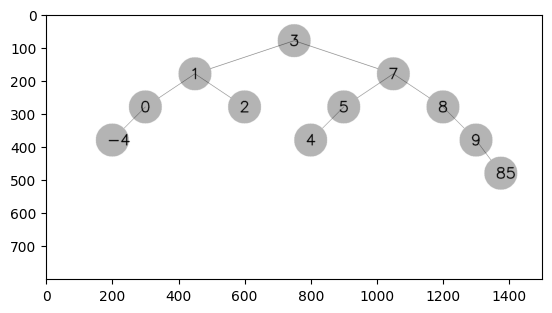

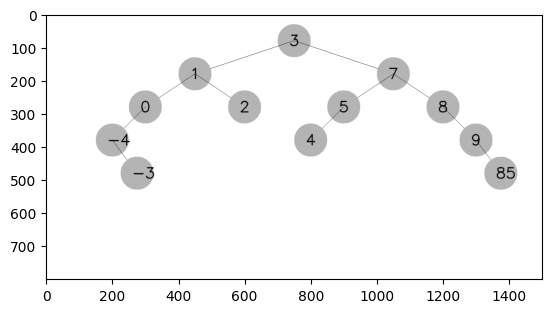

In [652]:
tree = Tree()

for i in [3,7,1,5,8,4,7,2,7,9,1,0,-4,85]:
    tree.insert(i)

WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)
plt.show()

tree.insert(-3)
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [620]:
tree.get_min().key, tree.get_max().key

(-4, 85)

In [621]:
tree.get_successor(tree.search(1)).key

2

In [622]:
tree.get_predecessor(tree.search(1)).key

0

In [623]:
#
# удаляем терминальную вершину
#

In [624]:
tree.delete(85)

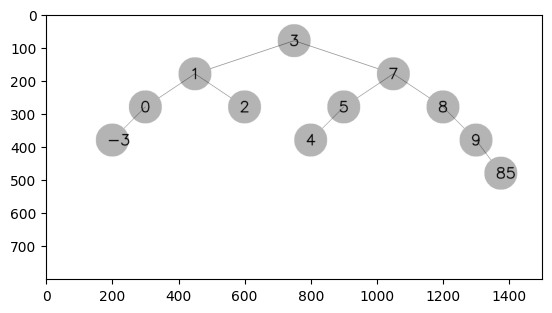

In [654]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [626]:
#
# удаляем корень с двумя существующими потомками
#

In [627]:
tree.delete(3)

None


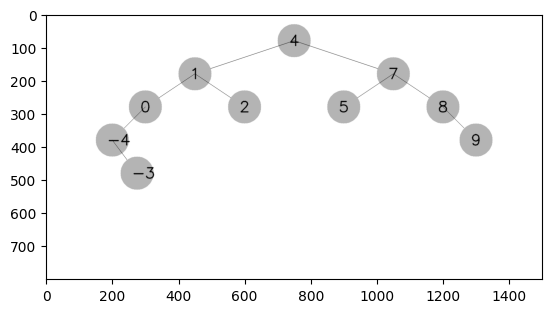

In [628]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [629]:
#
# удаляем вершину без правого потомка
#

In [630]:
tree.delete(0)

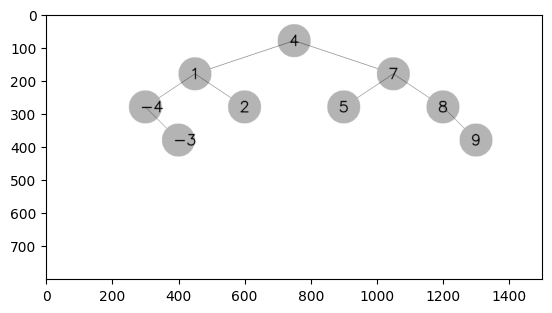

In [631]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [632]:
#
# удаляем вершину без левого потомка
#

In [633]:
tree.delete(8)

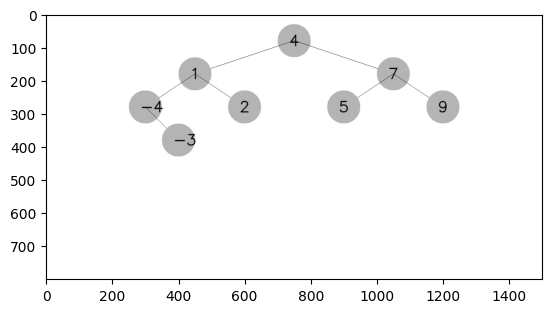

In [634]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [635]:
#
# удаляем вершину с двумя потомками
#

In [636]:
tree.delete(1)

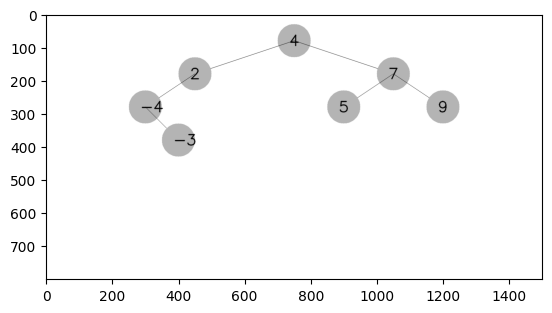

In [637]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [638]:
tree.delete(7)

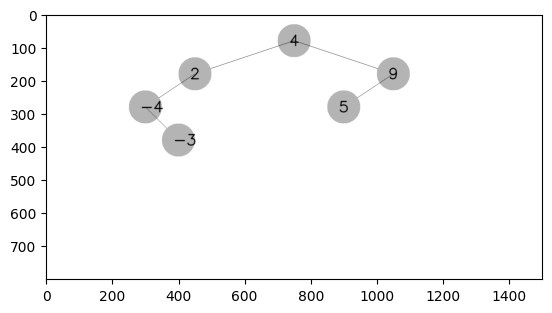

In [639]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [640]:
tree.delete(4)

None


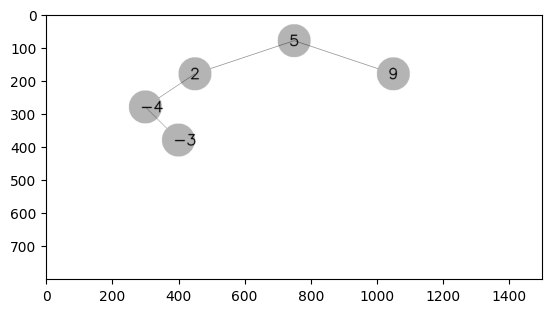

In [641]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [642]:
tree.delete(2)

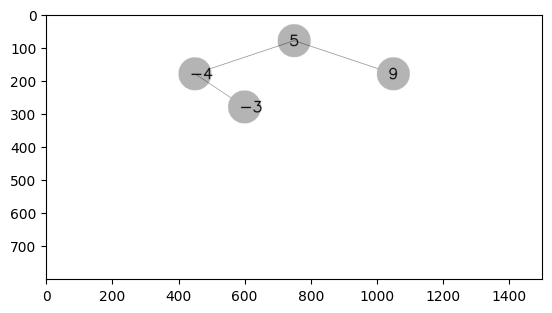

In [643]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [644]:
tree.delete(-3)

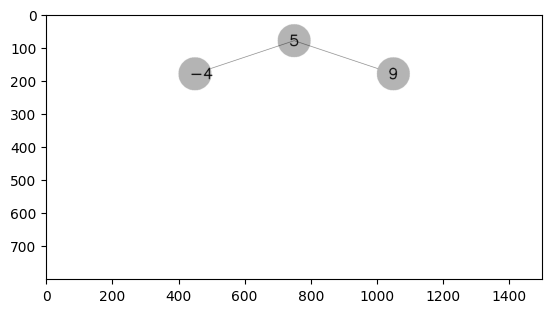

In [645]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [646]:
tree.delete(5)

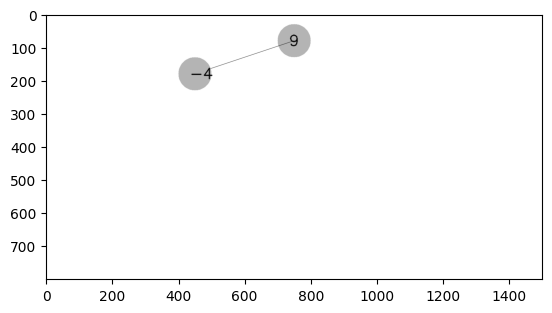

In [647]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [648]:
tree.delete(9)

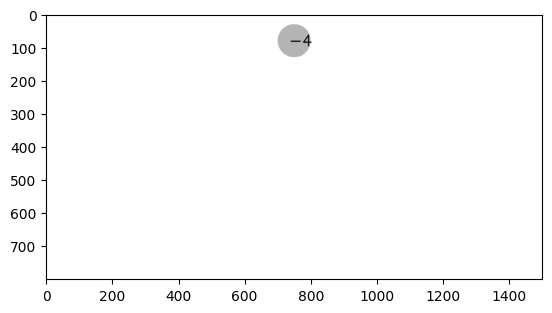

In [649]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)

In [650]:
tree.delete(tree.root.key)

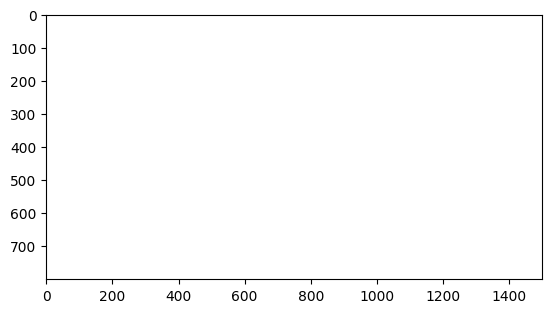

In [651]:
WINDY, WINDX = 800, 1500
canvas = np.ones((WINDY, WINDX, 3), np.uint8) * 255
tree.draw(canvas, x0 = WINDX // 2, y0 = WINDY // 10, h = 100, w = 300)
plt.imshow(canvas)